In [3]:
# 랭그래프는 각 노드에서 처리한 결과를 상태에서 관리하고, 각 노드를 엣지로 연결하는 그래프 형태로 표현하여 대화나 데이터 흐름을 관리
from langchain_openai import ChatOpenAI

model = ChatOpenAI(model="gpt-4o-mini")
model.invoke("안녕하세요")

AIMessage(content='안녕하세요! 무엇을 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 11, 'prompt_tokens': 9, 'total_tokens': 20, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_43b64008fd', 'id': 'chatcmpl-DZSG9GgKabgn9fDt2Dj1aefKGqidP', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019dd1dd-f789-7871-b827-5b940bb69965-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 9, 'output_tokens': 11, 'total_tokens': 20, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [4]:
# 상태(state): 노드가 작업한 결과를 기록해 두는 작업 일지를 의미 
# - 랭그래프에서 상태는 언어 모델이 임무를 수행하면서 현재 상태를 명확히 관리할 수 있도록 돕는 요소
## 상태 정의하기
from typing import Annotated # Annotated는 타입 힌트를 사용할 때 사용하는 함수
from typing_extensions import TypedDict # TypedDict 딕셔너리 타입을 정의할 때 사용하는 함수

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

class State(TypedDict) :
    """
    State 클래스는 TypeDict를 상속받습니다.
    
    속성:
        messages (Annotated[list[str],add_messages]): 메시지들은 "list" 타입을 가집니다.
        'add_messages' 함수는 이 상태 키가 어떻게 업데이트되어야 하는지를 정의합니다.
        (이 경우, 메시지를 덮어쓰는 대신 리스트에 추가합니다.)
    """ 
    messages: Annotated[list[str], add_messages]
    
graph_builder = StateGraph(State)

In [5]:
# 노드(node): 하나의 작업이자 단계를 의미 
## 노드 생성하기 
### 사용자가 질문하면 답변을 생성하는 generate라는 노드를 가진 랭그래프
### - 기존의 대화 내용에 기반하여 GPT로 답변을 생헝하는 역할


def generate(state:State):
    """
    주어진 상태를 기반으로 챗봇의 응답 메시지를 생성합니다.

    매개변수(Args):
        state (State):  현재 대화 상태를 나타내는 객체로, 이전 메시지들이 포함되어 있습니다.
    
    반환값:
        dict:   모델이 생성한 응답 메시지를 포함하는 딕셔너리.
                형식은 {"messages":[응답 메세지]}입니다.
    """
    return {"messages":[model.invoke(state["messages"])]}

graph_builder.add_node("generate",generate)



In [ ]:
# 엣지(Edge)
## 엣지 설정하기
## - 노드 앞뒤로 START와 END 노드를 지정하고 엣지를 설정

graph_builder.add_edge(START,"generate")
graph_builder.add_edge("generate",END)



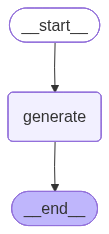

In [8]:
# 그래프 컴파일 및 시각화
graph = graph_builder.compile()
from IPython.display import Image, display
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [10]:
res = graph.invoke({"messages":["안녕하세요. 저는 김땡땡입니다."]})
print(type(res))
res

<class 'dict'>


{'messages': [HumanMessage(content='안녕하세요. 저는 김땡땡입니다.', additional_kwargs={}, response_metadata={}, id='45589270-9006-4bdf-b50b-18339fb11e04'),
  AIMessage(content='안녕하세요, 김땡땡님! 어떻게 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 20, 'total_tokens': 39, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_9490d6845c', 'id': 'chatcmpl-DZSNH1bzB6I30wLKnbdtFoOBeb4CO', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019dd1e4-ba58-7e43-89c4-a1f1ba082740-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 20, 'output_tokens': 19, 'total_tokens': 39, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_de

In [11]:
res['messages'].append("제 이름을 아시나요?")
graph.invoke(res)

{'messages': [HumanMessage(content='안녕하세요. 저는 김땡땡입니다.', additional_kwargs={}, response_metadata={}, id='45589270-9006-4bdf-b50b-18339fb11e04'),
  AIMessage(content='안녕하세요, 김땡땡님! 어떻게 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 20, 'total_tokens': 39, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_9490d6845c', 'id': 'chatcmpl-DZSNH1bzB6I30wLKnbdtFoOBeb4CO', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019dd1e4-ba58-7e43-89c4-a1f1ba082740-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 20, 'output_tokens': 19, 'total_tokens': 39, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_de

In [12]:
inputs = {"messages":[("human","한국과 일본의 관계에 대해 자세히 알려 줘.")]}
for chunk, _ in graph.stream(inputs,stream_mode="messages"):
    print(chunk.content,end="")

한국과 일본의 관계는 역사적으로 매우 복잡하고 다층적입니다. 두 나라 간의 관계는 정치, 경제, 사회문화적 측면에서 다양한 요소가 얽혀 있습니다. 다음은 한국과 일본의 관계를 이해하는 데 도움이 되는 몇 가지 주요 사항입니다.

### 역사적 배경
1. **조선 시대**: 한국과 일본은 역사적으로 교류가 있었지만, 조선 시대에는 일본의 침략과 약탈이 빈번했습니다. 특히, 1592년부터 1598년까지의 임진왜란은 두 나라 간의 관계에 큰 영향을 미쳤습니다.

2. **일제강점기 (1910-1945)**: 일본은 1910년부터 1945년까지 한반도를 강제 점령했습니다. 이 시기에 많은 한국인들이 탄압받고, 문화가 억압당했습니다. 이 경험은 현재까지도 두 나라 간의 긴장과 갈등의 주요 원인이 되고 있습니다.

### 정치적 관계
1. **외교적 갈등**: 한국과 일본은 역사 문제, 특히 일제강점기와 관련된 문제로 갈등이 있습니다. 대표적인 이슈로는 강제징용, 위안부 문제 등이 있으며, 이러한 사안들은 양국 간의 외교 관계에 부정적인 영향을 미치고 있습니다.

2. **안보 협력**: 그럼에도 불구하고, 북한의 군사적 위협에 대해 한국과 일본은 미국과의 삼각 동맹을 통해 안보 협력을 강화하고 있습니다. 이로 인해 양국 간에 전략적 관계도 존재합니다.

### 경제적 관계
1. **무역**: 한국과 일본은 경제적으로 긴밀하게 연결되어 있습니다. 두 나라는 서로의 주요 무역 파트너국이며, 전자, 자동차, 반도체 등 다양한 산업 분야에서 협력이 이루어지고 있습니다.

2. **전략적 경쟁**: 그러나 경제적 협력에도 불구하고, 기술과 시장 점유율을 놓고 서로 경쟁하는 경우도 많습니다. 특히 최근 몇 년 동안 일본의 수출 규제가 한국과의 경제적 긴장을 더욱 악화시켰습니다.

### 사회문화적 관계
1. **문화 교류**: K-팝, 한국 드라마, 음식 등 한국의 문화가 일본에서도 인기를 끌고 있습니다. 반대로 일본의 애니메이션과 영화 또한 한국에서 많은 사랑을 받고 있습니다.